# Session 4 — Parametric Test Statistics

**Course: Event Studies in Finance & Economics**

*Mathis Mourey*

---

Session 3 constructed the aggregation machinery: AAR, CAAR, weighting schemes, standardized abnormal returns, and the reusable toolkit. But aggregation alone does not constitute a test. To ask whether the CAAR is statistically significantly different from zero, we need a test statistic with a known distribution under the null hypothesis.

This session develops the four principal parametric tests used in the event study literature. We begin with the classical cross-sectional t-test (Brown and Warner, 1980, 1985), which uses the realized cross-sectional dispersion of abnormal returns and is robust to cross-sectional correlation by construction. We then introduce the Patell (1976) test, which standardizes each firm's abnormal return by its time-series standard deviation before aggregating, improving power when firms have heterogeneous volatilities. The Boehmer, Musumeci, and Poulsen (1991) (BMP) test combines the Patell standardization with the cross-sectional variance estimator, providing robustness to both heteroskedasticity and event-induced variance increases. Finally, we implement the Kolari and Pynnonen (2010) adjustment, which corrects for the cross-sectional correlation of abnormal returns that arises when events cluster in calendar time.

We apply all four tests to the same dataset used in Sessions 2 and 3 and compare the results. When the tests agree, we can be confident in the conclusion. When they disagree, the pattern of disagreement is informative about the structure of the data.

**References for this session:**

- Boehmer, E., Masumeci, J. and Poulsen, A.B. (1991). Event-Study Methodology Under Conditions of Event-Induced Variance. *Journal of Financial Economics*, 30(2), 253--272.
- Brown, S.J. and Warner, J.B. (1980). Measuring Security Price Performance. *Journal of Financial Economics*, 8(3), 205--258.
- Brown, S.J. and Warner, J.B. (1985). Using Daily Stock Returns. *Journal of Financial Economics*, 14(1), 3--31.
- Campbell, J.Y., Lo, A.W. and MacKinlay, A.C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 4.
- Kolari, J.W. and Pynnonen, S. (2010). Event Study Testing with Cross-sectional Correlation of Abnormal Returns. *Review of Financial Studies*, 23(11), 3996--4025.
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13--39.
- Patell, J.M. (1976). Corporate Forecasts of Earnings Per Share and Stock Price Behavior. *Journal of Accounting Research*, 14(2), 246--276.

## 1. The Testing Problem

The null hypothesis in an event study is that the event has no effect on stock prices:

$$
H_0: \; CAAR(\tau_a, \tau_b) = 0
$$

The alternative is that the event does affect prices, and the direction depends on the research question. For earnings announcements, we typically test a two-sided alternative; for corporate scandals or regulatory shocks, a one-sided alternative may be appropriate.

Under the null, abnormal returns are simply the estimation error of the normal return model:

$$
AR_{i,\tau} = \varepsilon_{i,\tau} \quad \text{under } H_0
$$

A test statistic takes the general form:

$$
T = \frac{\text{Estimate of CAAR}}{\text{Estimated standard error of CAAR}}
$$

The four tests we develop differ in how they estimate the numerator and, more importantly, the denominator. The denominator is where the assumptions enter: assumptions about cross-sectional independence, homoskedasticity, and whether the event itself changes the variance of returns.

## 2. Data and Setup

We use the same sample of earnings announcements as in Sessions 2 and 3. The data pipeline below is identical to Session 3: we download price data, estimate the market model for each firm over a 250-day estimation window, and compute abnormal returns in a $[-10, +10]$ event window. The output is the panel of abnormal returns and the model parameters needed for the test statistics.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# -- Sample: same as Sessions 2 and 3 --
events = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'JPM', 'JNJ', 'V', 'PG'],
    'event_date': pd.to_datetime([
        '2024-02-01', '2024-01-30', '2024-01-30', '2024-02-01',
        '2024-02-01', '2024-02-21', '2024-01-12', '2024-01-23',
        '2024-01-25', '2024-01-23'
    ]),
    'name': ['Apple', 'Microsoft', 'Alphabet', 'Amazon', 'Meta',
             'Nvidia', 'JPMorgan', 'Johnson & Johnson', 'Visa', 'Procter & Gamble']
})

market_ticker = '^GSPC'
start_date = '2022-06-01'
end_date = '2024-04-01'

data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)
if isinstance(data_market.columns, pd.MultiIndex):
    data_market.columns = data_market.columns.get_level_values(0)
market_prices = data_market['Close']

all_tickers = events['ticker'].tolist()
data_firms = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
if isinstance(data_firms.columns, pd.MultiIndex):
    firm_prices = data_firms['Close']
else:
    firm_prices = data_firms[['Close']].rename(columns={'Close': all_tickers[0]})

market_returns = market_prices.pct_change().dropna()
firm_returns = firm_prices.pct_change().dropna()

common_idx = market_returns.index.intersection(firm_returns.index)
market_returns = market_returns.loc[common_idx]
firm_returns = firm_returns.loc[common_idx]

print(f"Sample: {len(events)} firms, {len(common_idx)} trading days")
print(f"Period: {common_idx[0].date()} to {common_idx[-1].date()}")

YF.download() has changed argument auto_adjust default to True
Sample: 10 firms, 458 trading days
Period: 2022-06-02 to 2024-03-28


In [3]:
# -- Estimation and event window parameters --
est_window_length = 250
buffer = 10
event_win = (-10, 10)
event_days = list(range(event_win[0], event_win[1] + 1))
trading_days = firm_returns.index

# -- Estimate market model and compute ARs for each firm --
ar_panel = pd.DataFrame(index=event_days, columns=events['ticker'].values, dtype=float)
model_params = {}

for _, row in events.iterrows():
    tick = row['ticker']
    edate = row['event_date']

    event_idx = trading_days.get_indexer([edate], method='ffill')[0]
    event_start = event_idx + event_win[0]
    event_end = event_idx + event_win[1]
    est_end = event_start - buffer - 1
    est_start = est_end - est_window_length + 1

    if est_start < 0:
        print(f"  {tick}: insufficient data, skipping")
        continue

    y_est = firm_returns.iloc[est_start:est_end + 1][tick].values
    x_est = market_returns.iloc[est_start:est_end + 1].values
    valid = ~(np.isnan(y_est) | np.isnan(x_est))
    y_est, x_est = y_est[valid], x_est[valid]
    X_est = sm.add_constant(x_est)
    ols = sm.OLS(y_est, X_est).fit()
    alpha, beta = ols.params[0], ols.params[1]
    sigma = np.sqrt(ols.mse_resid)

    y_evt = firm_returns.iloc[event_start:event_end + 1][tick].values
    x_evt = market_returns.iloc[event_start:event_end + 1].values
    ar = y_evt - (alpha + beta * x_evt)
    ar_panel[tick] = ar

    # Store parameters needed for test statistics
    model_params[tick] = {
        'alpha': alpha, 'beta': beta, 'sigma': sigma,
        'L': len(y_est),
        'x_bar': x_est.mean(),
        'x_ss': np.sum((x_est - x_est.mean()) ** 2),
        'ols': ols,
    }

N = ar_panel.shape[1]
print(f"\nSuccessfully processed {N} firms")
print(f"Event window: [{event_win[0]}, +{event_win[1]}] ({len(event_days)} days)")
print(f"Estimation window: {est_window_length} days with {buffer}-day buffer")


Successfully processed 10 firms
Event window: [-10, +10] (21 days)
Estimation window: 250 days with 10-day buffer


## 3. The Cross-Sectional t-Test (Brown and Warner, 1980, 1985)

The simplest and most widely used test statistic in event studies is the cross-sectional t-test introduced by Brown and Warner (1980, 1985). Its logic is straightforward. On each event day $\tau$, we have $N$ abnormal returns. Under the null, these are draws from a distribution with mean zero and some variance $\sigma^2_\tau$. We estimate $\sigma^2_\tau$ from the cross-sectional dispersion of the abnormal returns themselves.

The test statistic for the AAR on a single event day is:

$$
t_{CS}(\tau) = \frac{AAR(\tau)}{\hat{S}(\tau) / \sqrt{N}}
$$

where

$$
\hat{S}^2(\tau) = \frac{1}{N - 1} \sum_{i=1}^{N} \left(AR_{i,\tau} - AAR(\tau)\right)^2
$$

For the CAAR over a window $[\tau_a, \tau_b]$:

$$
t_{CS}(\tau_a, \tau_b) = \frac{CAAR(\tau_a, \tau_b)}{\hat{S}_{CAR} / \sqrt{N}}
$$

where $\hat{S}^2_{CAR}$ is the cross-sectional variance of the individual CARs:

$$
\hat{S}^2_{CAR} = \frac{1}{N - 1} \sum_{i=1}^{N} \left(CAR_i(\tau_a, \tau_b) - CAAR(\tau_a, \tau_b)\right)^2
$$

Under the null and standard regularity conditions, $t_{CS}$ follows a $t$-distribution with $N - 1$ degrees of freedom, which is well-approximated by the standard normal for $N > 30$.

The key property of this test is that the variance estimator is computed from the cross-section, not from the time series. This means it automatically captures any cross-sectional correlation in abnormal returns arising from calendar-time clustering. If all firms share a common shock on a given day (because their event windows overlap), that shock inflates the cross-sectional variance, which inflates the denominator, which makes the test more conservative. This is the correct behavior: the test does not over-reject when events cluster.

The limitation is that the test treats all firms equally, regardless of their return volatility. A firm with $\sigma_\varepsilon = 0.5\%$ and a firm with $\sigma_\varepsilon = 3\%$ contribute equally to the numerator and denominator. This reduces power when the sample includes firms with very different volatilities, which is common in practice.

In [5]:
# -- Cross-Sectional t-Test --

def cross_sectional_test(ar_panel, windows):
    # Brown-Warner cross-sectional t-test for AAR and CAAR.
    results = []
    N = ar_panel.shape[1]

    for tau_a, tau_b in windows:
        mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
        window_ar = ar_panel.loc[mask]

        # Individual CARs for this window
        cars = window_ar.sum(axis=0)
        caar = cars.mean()
        s_car = cars.std(ddof=1)
        t_stat = caar / (s_car / np.sqrt(N))
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=N - 1))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'CAAR (%)': caar * 100,
            'SE (%)': (s_car / np.sqrt(N)) * 100,
            't-stat': t_stat,
            'p-value': p_val,
            'N': N,
        })

    return pd.DataFrame(results)


windows = [(-10, 10), (-5, 5), (-1, 1), (0, 0), (0, 1), (1, 10)]
cs_results = cross_sectional_test(ar_panel, windows)
print("Cross-Sectional t-Test (Brown-Warner)")
print("=" * 70)
print(cs_results.to_string(index=False, float_format='{:.4f}'.format))

Cross-Sectional t-Test (Brown-Warner)
    Window  CAAR (%)  SE (%)  t-stat  p-value  N
[-10, +10]    1.7209  2.1693  0.7933   0.4480 10
  [-5, +5]    0.4700  1.7997  0.2611   0.7999 10
  [-1, +1]    1.6717  2.1020  0.7953   0.4469 10
  [+0, +0]   -0.4435  0.6136 -0.7228   0.4882 10
  [+0, +1]    1.9816  2.1732  0.9118   0.3856 10
 [+1, +10]    2.5479  2.6933  0.9460   0.3689 10


## 4. The Patell Test (1976)

The Patell test improves on the cross-sectional t-test by standardizing each firm's abnormal return before aggregation. As discussed in Session 3, the standardized abnormal return for firm $i$ on event day $\tau$ is:

$$
SAR_{i,\tau} = \frac{AR_{i,\tau}}{\hat{\sigma}_{\varepsilon_i} \cdot c_{i,\tau}}
$$

where $\hat{\sigma}_{\varepsilon_i}$ is the residual standard deviation from the estimation window and $c_{i,\tau}$ is the prediction error correction factor:

$$
c_{i,\tau} = \sqrt{1 + \frac{1}{L_i} + \frac{(R_{m,\tau} - \bar{R}_m)^2}{\sum_{t=1}^{L_i} (R_{m,t} - \bar{R}_m)^2}}
$$

The correction adjusts for the fact that the abnormal return in the event window is computed using estimated (not true) parameters. For long estimation windows ($L_i > 100$), this correction is close to one and is often omitted, but we include it here for completeness.

Under the null, $SAR_{i,\tau}$ has mean zero and variance that is approximately one (exactly one if the correction is included and the estimation window is long). The Patell test aggregates the standardized abnormal returns across firms:

$$
\overline{SAR}(\tau) = \frac{1}{N} \sum_{i=1}^{N} SAR_{i,\tau}
$$

For the cumulative standardized abnormal return over $[\tau_a, \tau_b]$:

$$
CSAR_i(\tau_a, \tau_b) = \frac{1}{\sqrt{T_w}} \sum_{\tau=\tau_a}^{\tau_b} SAR_{i,\tau}
$$

$$
T_{Patell} = \sqrt{N} \cdot \frac{1}{N} \sum_{i=1}^{N} CSAR_i(\tau_a, \tau_b)
$$

The $1/\sqrt{T_w}$ normalization ensures that $CSAR_i$ has unit variance under the null (assuming no serial correlation). The test statistic is asymptotically standard normal.

The Patell test is more powerful than the cross-sectional t-test when firms have heterogeneous volatilities, because standardization prevents high-volatility firms from dominating the average. However, it has an important limitation: it uses the time-series variance $\hat{\sigma}^2_{\varepsilon_i}$ from the estimation window as the denominator. If the event itself increases return variance (event-induced variance), the estimation-window variance underestimates the true event-window variance, and the test over-rejects. This problem motivates the BMP test.

In [7]:
# -- Patell Test --

def patell_test(ar_panel, model_params, market_returns, trading_days, events, event_win, windows):
    # Patell (1976) standardized residual test with prediction error correction.
    results = []
    N = ar_panel.shape[1]

    # Compute SAR panel with prediction error correction
    sar_panel = pd.DataFrame(index=ar_panel.index, columns=ar_panel.columns, dtype=float)

    for tick in ar_panel.columns:
        p = model_params[tick]
        sigma_i = p['sigma']
        L_i = p['L']
        x_bar = p['x_bar']
        x_ss = p['x_ss']

        edate = events.loc[events['ticker'] == tick, 'event_date'].values[0]
        event_idx = trading_days.get_indexer([edate], method='ffill')[0]

        for tau in ar_panel.index:
            idx = event_idx + tau
            if 0 <= idx < len(market_returns):
                r_m = market_returns.iloc[idx]
                c_tau = np.sqrt(1 + 1 / L_i + (r_m - x_bar) ** 2 / x_ss)
                sar_panel.loc[tau, tick] = ar_panel.loc[tau, tick] / (sigma_i * c_tau)

    for tau_a, tau_b in windows:
        mask = (sar_panel.index >= tau_a) & (sar_panel.index <= tau_b)
        window_sar = sar_panel.loc[mask]
        T_w = mask.sum()

        # Cumulative standardized AR for each firm
        csar = window_sar.sum(axis=0) / np.sqrt(T_w)
        t_stat = np.sqrt(N) * csar.mean()
        p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'Mean CSAR': csar.mean(),
            'T_Patell': t_stat,
            'p-value': p_val,
        })

    return pd.DataFrame(results), sar_panel


patell_results, sar_panel = patell_test(
    ar_panel, model_params, market_returns, trading_days, events, event_win, windows
)
print("Patell Test (Standardized Residual Test)")
print("=" * 60)
print(patell_results.to_string(index=False, float_format='{:.4f}'.format))

Patell Test (Standardized Residual Test)
    Window  Mean CSAR  T_Patell  p-value
[-10, +10]     0.1068    0.3379   0.7355
  [-5, +5]    -0.0753   -0.2380   0.8119
  [-1, +1]     0.2735    0.8648   0.3871
  [+0, +0]    -0.0868   -0.2744   0.7838
  [+0, +1]     0.4073    1.2881   0.1977
 [+1, +10]     0.2122    0.6709   0.5023


## 5. The BMP Test (Boehmer, Musumeci, Poulsen, 1991)

The BMP test addresses the main weakness of the Patell test: its sensitivity to event-induced variance changes. The idea is simple but effective. Rather than using the time-series variance from the estimation window to normalize the test statistic, the BMP test uses the cross-sectional variance of the standardized abnormal returns in the event window.

Formally, the BMP test statistic is:

$$
T_{BMP} = \frac{\overline{CSAR}}{\hat{S}_{CSAR} / \sqrt{N}}
$$

where $\overline{CSAR} = \frac{1}{N} \sum_{i=1}^{N} CSAR_i$ is the average cumulative standardized abnormal return and $\hat{S}_{CSAR}$ is its cross-sectional standard deviation:

$$
\hat{S}^2_{CSAR} = \frac{1}{N - 1} \sum_{i=1}^{N} \left(CSAR_i - \overline{CSAR}\right)^2
$$

The test has the structure of a standard t-test on the $CSAR_i$ values, and follows a $t$-distribution with $N - 1$ degrees of freedom under the null.

The BMP test combines the best properties of the preceding tests. From the Patell test, it inherits the standardization that equalizes the contribution of each firm. From the cross-sectional t-test, it inherits the cross-sectional variance estimator that is robust to event-induced variance. If the event increases return variance uniformly across firms, the SAR magnitudes remain centered at zero but become more dispersed; the cross-sectional variance captures this increased dispersion, and the denominator adjusts accordingly.

This test has become the workhorse of the applied event study literature. Kolari and Pynnonen (2010) show, in a comprehensive simulation study, that the BMP test is well-specified (correct size) under a wide range of conditions, including event-induced variance, non-normality of returns, and moderate cross-sectional dependence.

In [10]:
# -- BMP Test --

def bmp_test(sar_panel, windows):
    # Boehmer-Musumeci-Poulsen (1991) test.
    # Uses cross-sectional variance of standardized CARs.
    results = []
    N = sar_panel.shape[1]

    for tau_a, tau_b in windows:
        mask = (sar_panel.index >= tau_a) & (sar_panel.index <= tau_b)
        window_sar = sar_panel.loc[mask]
        T_w = mask.sum()

        csar = window_sar.sum(axis=0) / np.sqrt(T_w)
        csar_mean = csar.mean()
        csar_std = csar.std(ddof=1)
        t_stat = csar_mean / (csar_std / np.sqrt(N))
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=N - 1))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'Mean CSAR': csar_mean,
            'SD CSAR': csar_std,
            'T_BMP': t_stat,
            'p-value': p_val,
        })

    return pd.DataFrame(results)


bmp_results = bmp_test(sar_panel, windows)
print("BMP Test (Boehmer-Musumeci-Poulsen)")
print("=" * 65)
print(bmp_results.to_string(index=False, float_format='{:.4f}'.format))

BMP Test (Boehmer-Musumeci-Poulsen)
    Window  Mean CSAR  SD CSAR   T_BMP  p-value
[-10, +10]     0.1068   1.0422  0.3242   0.7532
  [-5, +5]    -0.0753   1.2691 -0.1875   0.8554
  [-1, +1]     0.2735   2.2256  0.3886   0.7066
  [+0, +0]    -0.0868   1.7420 -0.1575   0.8783
  [+0, +1]     0.4073   2.7598  0.4667   0.6518
 [+1, +10]     0.2122   1.3966  0.4804   0.6424


## 6. The Kolari-Pynnonen Adjustment for Cross-Sectional Correlation (2010)

The BMP test is robust to event-induced variance but assumes that the standardized abnormal returns are cross-sectionally independent. When events cluster in calendar time, the SARs share a common component (the market model residual on the same calendar date), and the cross-sectional variance underestimates the true variance of the average SAR. The result is over-rejection.

Kolari and Pynnonen (2010) propose a simple adjustment. They multiply the BMP test statistic by a deflation factor that depends on the average cross-sectional correlation of abnormal returns:

$$
T_{KP} = T_{BMP} \cdot \sqrt{\frac{1 - \bar{r}}{1 + (N-1)\bar{r}}}
$$

where $\bar{r}$ is the average pairwise correlation of the abnormal returns in the estimation window:

$$
\bar{r} = \frac{2}{N(N-1)} \sum_{i=1}^{N} \sum_{j>i} \hat{\rho}_{ij}
$$

and $\hat{\rho}_{ij}$ is the sample correlation between the estimation-window residuals of firms $i$ and $j$.

The adjustment factor is always less than or equal to one (since $\bar{r} \geq 0$ when there is positive cross-correlation), so $|T_{KP}| \leq |T_{BMP}|$. The test becomes more conservative as the average cross-correlation increases, which is the desired behavior when clustering is present.

When $\bar{r} = 0$ (no cross-correlation), the adjustment factor equals one and $T_{KP} = T_{BMP}$. When $\bar{r} = 1$ (perfect correlation, all firms are exposed to the same shock), the adjustment factor goes to zero, reflecting the fact that $N$ perfectly correlated observations provide no more information than a single observation.

In our sample, several earnings announcements fall on the same dates. We therefore expect $\bar{r} > 0$ and $|T_{KP}| < |T_{BMP}|$.

In [13]:
# -- Kolari-Pynnonen Adjustment --

def kolari_pynnonen_test(ar_panel, sar_panel, model_params, events, trading_days,
                         est_window_length, buffer, event_win, windows):
    # Kolari-Pynnonen (2010) adjusted BMP test.
    # Corrects for cross-sectional correlation using estimation-window residuals.
    N = ar_panel.shape[1]
    tickers = ar_panel.columns.tolist()

    # Compute estimation-window residuals for all firms on a common calendar
    residual_dict = {}
    for tick in tickers:
        p = model_params[tick]
        edate = events.loc[events['ticker'] == tick, 'event_date'].values[0]
        event_idx = trading_days.get_indexer([edate], method='ffill')[0]
        event_start = event_idx + event_win[0]
        est_end = event_start - buffer - 1
        est_start = est_end - est_window_length + 1

        dates = trading_days[est_start:est_end + 1]
        y = firm_returns.iloc[est_start:est_end + 1][tick].values
        x = market_returns.iloc[est_start:est_end + 1].values
        resid = y - (p['alpha'] + p['beta'] * x)
        residual_dict[tick] = pd.Series(resid, index=dates)

    resid_df = pd.DataFrame(residual_dict).dropna()

    # Average pairwise correlation
    corr_matrix = resid_df.corr()
    mask_upper = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
    r_bar = corr_matrix.values[mask_upper].mean()

    # Adjustment factor
    adj = np.sqrt((1 - r_bar) / (1 + (N - 1) * r_bar))

    # BMP statistics, then apply adjustment
    results = []
    for tau_a, tau_b in windows:
        mask_w = (sar_panel.index >= tau_a) & (sar_panel.index <= tau_b)
        window_sar = sar_panel.loc[mask_w]
        T_w = mask_w.sum()

        csar = window_sar.sum(axis=0) / np.sqrt(T_w)
        csar_mean = csar.mean()
        csar_std = csar.std(ddof=1)
        t_bmp = csar_mean / (csar_std / np.sqrt(N))
        t_kp = t_bmp * adj
        p_val = 2 * (1 - stats.t.cdf(abs(t_kp), df=N - 1))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'T_BMP': t_bmp,
            'r_bar': r_bar,
            'Adj. factor': adj,
            'T_KP': t_kp,
            'p-value': p_val,
        })

    return pd.DataFrame(results), r_bar


kp_results, r_bar = kolari_pynnonen_test(
    ar_panel, sar_panel, model_params, events, trading_days,
    est_window_length, buffer, event_win, windows
)
print("Kolari-Pynnonen Adjusted BMP Test")
print("=" * 72)
print(f"Average pairwise correlation of estimation-window residuals: {r_bar:.4f}")
print()
print(kp_results.to_string(index=False, float_format='{:.4f}'.format))

Kolari-Pynnonen Adjusted BMP Test
Average pairwise correlation of estimation-window residuals: 0.0023

    Window   T_BMP  r_bar  Adj. factor    T_KP  p-value
[-10, +10]  0.3242 0.0023       0.9886  0.3205   0.7559
  [-5, +5] -0.1875 0.0023       0.9886 -0.1854   0.8570
  [-1, +1]  0.3886 0.0023       0.9886  0.3842   0.7098
  [+0, +0] -0.1575 0.0023       0.9886 -0.1557   0.8797
  [+0, +1]  0.4667 0.0023       0.9886  0.4614   0.6554
 [+1, +10]  0.4804 0.0023       0.9886  0.4749   0.6462


## 7. Comparing the Four Tests

We now collect the results from all four tests into a single table for each event window. The comparison reveals two things: whether the conclusions are robust across tests, and where the tests disagree and why.

When the cross-sectional t-test and the Patell test give similar results, the heterogeneity of firm-level volatilities is not a major concern. When the Patell test rejects but the BMP test does not, the Patell test is likely over-rejecting due to event-induced variance. When the BMP test and the Kolari-Pynnonen test diverge, cross-sectional correlation (calendar-time clustering) is inflating the BMP statistic.

In [29]:
# -- Consolidate all four tests --

summary_rows = []
for i, (tau_a, tau_b) in enumerate(windows):
    label = f'[{tau_a:+d}, {tau_b:+d}]'
    mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
    cars = ar_panel.loc[mask].sum(axis=0)
    caar = cars.mean() * 100

    summary_rows.append({
        'Window': label,
        'CAAR (%)': caar,
        't_CS': cs_results.iloc[i]['t-stat'],
        'p_CS': cs_results.iloc[i]['p-value'],
        't_Patell': patell_results.iloc[i]['T_Patell'],
        'p_Patell': patell_results.iloc[i]['p-value'],
        't_BMP': bmp_results.iloc[i]['T_BMP'],
        'p_BMP': bmp_results.iloc[i]['p-value'],
        't_KP': kp_results.iloc[i]['T_KP'],
        'p_KP': kp_results.iloc[i]['p-value'],
    })

summary = pd.DataFrame(summary_rows)

print("Comparison of Parametric Test Statistics")
print("=" * 95)

# Print t-statistics
cols_t = ['Window', 'CAAR (%)', 't_CS', 't_Patell', 't_BMP', 't_KP']
print("\nPanel A: Test Statistics")
print(summary[cols_t].to_string(index=False, float_format='{:.3f}'.format))

# Print p-values
cols_p = ['Window', 'p_CS', 'p_Patell', 'p_BMP', 'p_KP']
print("\nPanel B: p-values")
print(summary[cols_p].to_string(index=False, float_format='{:.4f}'.format))

Comparison of Parametric Test Statistics

Panel A: Test Statistics
    Window  CAAR (%)   t_CS  t_Patell  t_BMP   t_KP
[-10, +10]     1.721  0.793     0.338  0.324  0.320
  [-5, +5]     0.470  0.261    -0.238 -0.188 -0.185
  [-1, +1]     1.672  0.795     0.865  0.389  0.384
  [+0, +0]    -0.443 -0.723    -0.274 -0.158 -0.156
  [+0, +1]     1.982  0.912     1.288  0.467  0.461
 [+1, +10]     2.548  0.946     0.671  0.480  0.475

Panel B: p-values
    Window   p_CS  p_Patell  p_BMP   p_KP
[-10, +10] 0.4480    0.7355 0.7532 0.7559
  [-5, +5] 0.7999    0.8119 0.8554 0.8570
  [-1, +1] 0.4469    0.3871 0.7066 0.7098
  [+0, +0] 0.4882    0.7838 0.8783 0.8797
  [+0, +1] 0.3856    0.1977 0.6518 0.6554
 [+1, +10] 0.3689    0.5023 0.6424 0.6462


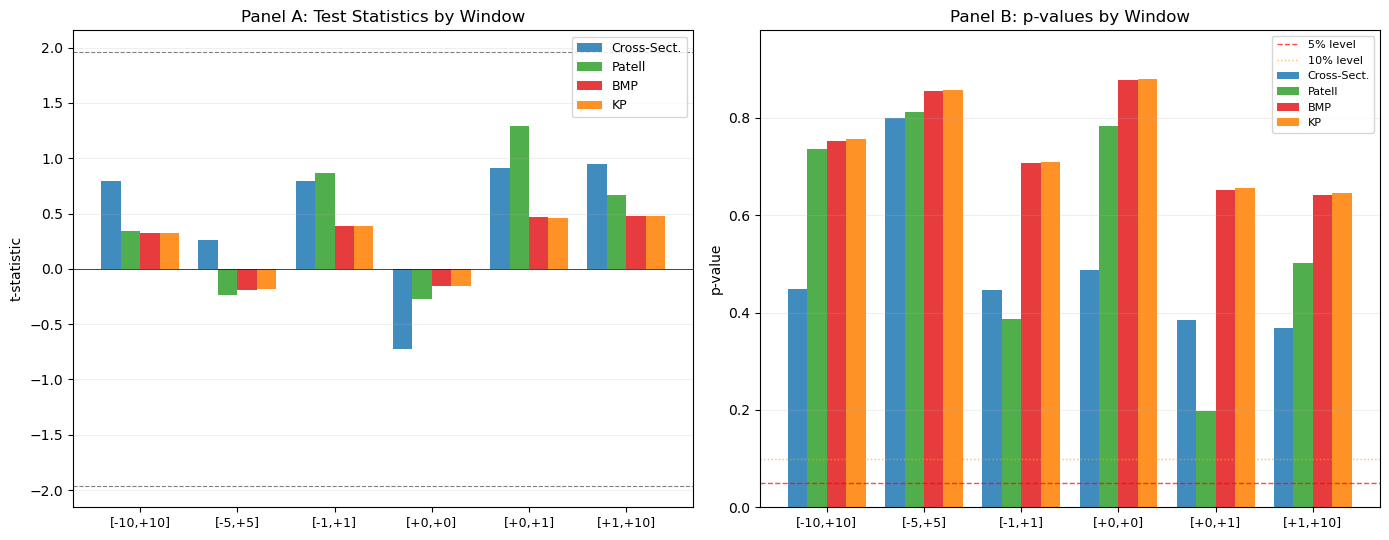

In [31]:
# -- Visual comparison --

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x_pos = np.arange(len(windows))
width = 0.2
labels = [f'[{a:+d},{b:+d}]' for a, b in windows]

# Panel A: t-statistics
ax = axes[0]
ax.bar(x_pos - 1.5 * width, summary['t_CS'], width, label='Cross-Sect.', color='#1f78b4', alpha=0.85)
ax.bar(x_pos - 0.5 * width, summary['t_Patell'], width, label='Patell', color='#33a02c', alpha=0.85)
ax.bar(x_pos + 0.5 * width, summary['t_BMP'], width, label='BMP', color='#e31a1c', alpha=0.85)
ax.bar(x_pos + 1.5 * width, summary['t_KP'], width, label='KP', color='#ff7f00', alpha=0.85)
ax.axhline(1.96, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(-1.96, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('t-statistic')
ax.set_title('Panel A: Test Statistics by Window')
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.2, axis='y')

# Panel B: p-values
ax = axes[1]
ax.bar(x_pos - 1.5 * width, summary['p_CS'], width, label='Cross-Sect.', color='#1f78b4', alpha=0.85)
ax.bar(x_pos - 0.5 * width, summary['p_Patell'], width, label='Patell', color='#33a02c', alpha=0.85)
ax.bar(x_pos + 0.5 * width, summary['p_BMP'], width, label='BMP', color='#e31a1c', alpha=0.85)
ax.bar(x_pos + 1.5 * width, summary['p_KP'], width, label='KP', color='#ff7f00', alpha=0.85)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, alpha=0.7, label='5% level')
ax.axhline(0.10, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='10% level')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('p-value')
ax.set_title('Panel B: p-values by Window')
ax.legend(fontsize=8, frameon=True)
ax.set_ylim(0, min(1.0, summary[['p_CS', 'p_Patell', 'p_BMP', 'p_KP']].max().max() + 0.1))
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

## 8. Event-Induced Variance

A recurring theme in this session is the possibility that the event itself changes the variance of returns. This phenomenon is well-documented for earnings announcements, mergers, and other corporate events. On announcement day, the variance of returns is typically two to five times higher than on non-event days (Beaver, 1968; Patell and Wolfson, 1979).

Event-induced variance has asymmetric effects on the test statistics. The cross-sectional t-test and the BMP test are robust to it, because they estimate variance from the event-window data. The Patell test is not robust, because it uses the estimation-window variance, which reflects normal-period volatility. The result is that the Patell test over-rejects when event-induced variance is present: the denominator is too small, so the test statistic is too large.

We can test for event-induced variance directly by comparing the cross-sectional variance of abnormal returns on each event day to the average cross-sectional variance in the estimation window.

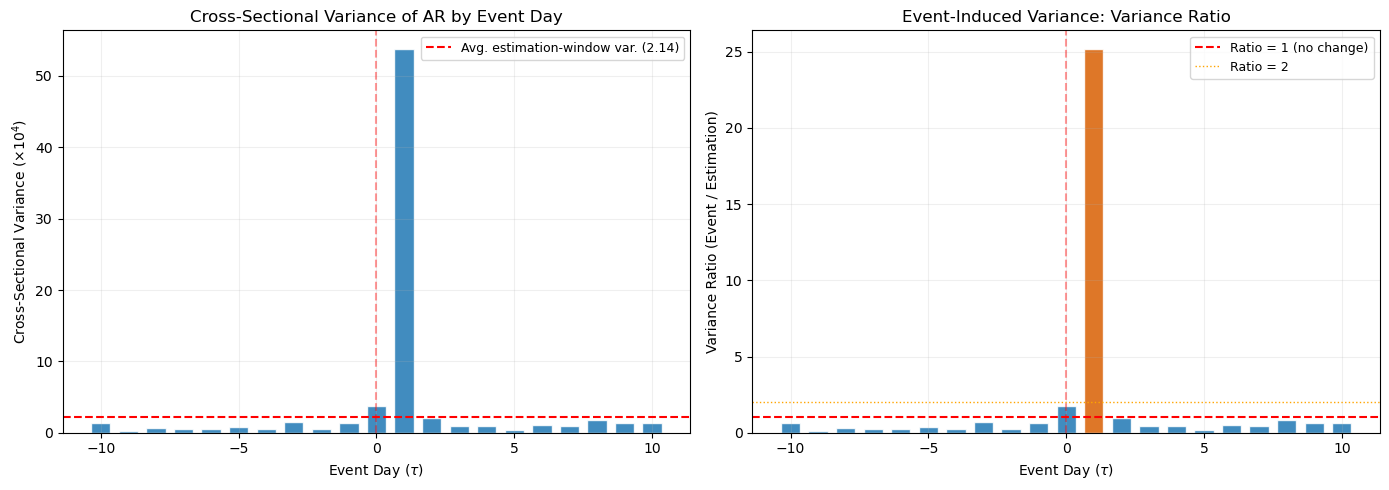

Days with variance ratio > 2.0 (event-induced variance likely present):
  Day +1: ratio = 25.14

Avg. variance ratio across all event days: 1.70
Variance ratio on day 0: 1.76


In [33]:
# -- Event-Induced Variance Analysis --

# Cross-sectional variance of AR on each event day
cs_var_event = ar_panel.var(axis=1, ddof=1)

# Average estimation-window variance across firms
avg_ts_var = np.mean([model_params[t]['sigma'] ** 2 for t in ar_panel.columns])

# Variance ratio: event-day variance / estimation-window variance
var_ratio = cs_var_event / avg_ts_var

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(event_days, cs_var_event * 1e4, color='#1f78b4', edgecolor='white', width=0.7, alpha=0.85)
ax.axhline(avg_ts_var * 1e4, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg. estimation-window var. ({avg_ts_var*1e4:.2f})')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.4)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('Cross-Sectional Variance ($\\times 10^4$)')
ax.set_title('Cross-Sectional Variance of AR by Event Day')
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.2)

ax = axes[1]
colors = ['#d95f02' if v > 2.0 else '#1f78b4' for v in var_ratio]
ax.bar(event_days, var_ratio, color=colors, edgecolor='white', width=0.7, alpha=0.85)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Ratio = 1 (no change)')
ax.axhline(2.0, color='orange', linestyle=':', linewidth=1, label='Ratio = 2')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.4)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('Variance Ratio (Event / Estimation)')
ax.set_title('Event-Induced Variance: Variance Ratio')
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Report days with elevated variance
elevated = var_ratio[var_ratio > 2.0]
if len(elevated) > 0:
    print("Days with variance ratio > 2.0 (event-induced variance likely present):")
    for tau, vr in elevated.items():
        print(f"  Day {tau:+d}: ratio = {vr:.2f}")
else:
    print("No event days show a variance ratio exceeding 2.0.")
print(f"\nAvg. variance ratio across all event days: {var_ratio.mean():.2f}")
print(f"Variance ratio on day 0: {var_ratio.loc[0]:.2f}")

## 9. Size and Power: A Simulation Perspective

The test statistics developed above are evaluated on two criteria. **Size** (or significance level) is the probability of rejecting the null when it is true. A well-specified test at the 5% level should reject in approximately 5% of random samples. **Power** is the probability of rejecting the null when it is false. A powerful test detects genuine abnormal returns with high probability.

Brown and Warner (1985) established the simulation framework that has become standard for evaluating event study test statistics. The procedure is as follows. We draw random samples of event dates (from non-event periods) and apply the test. Under the null, no abnormal return is present. If the test rejects more often than the nominal size, it is over-sized (too many false positives). If we then inject a known abnormal return and the test rejects more often, it has power against that alternative.

We implement a simplified version of this framework below. We draw 1,000 random pseudo-event samples from the estimation-window data and compute all four test statistics. The empirical rejection rates at the 5% level are the estimated size of each test.

In [35]:
# -- Size Simulation --
np.random.seed(42)
n_simulations = 1000
alpha_level = 0.05
test_window = (-1, 1)

# Use estimation-window residuals as the population of "no-event" returns
all_residuals = {}
for tick in ar_panel.columns:
    p = model_params[tick]
    edate = events.loc[events['ticker'] == tick, 'event_date'].values[0]
    event_idx = trading_days.get_indexer([edate], method='ffill')[0]
    event_start = event_idx + event_win[0]
    est_end = event_start - buffer - 1
    est_start = est_end - est_window_length + 1
    y = firm_returns.iloc[est_start:est_end + 1][tick].values
    x = market_returns.iloc[est_start:est_end + 1].values
    resid = y - (p['alpha'] + p['beta'] * x)
    all_residuals[tick] = resid

tickers = list(all_residuals.keys())
T_w = test_window[1] - test_window[0] + 1

rejections = {'CS': 0, 'Patell': 0, 'BMP': 0}

for sim in range(n_simulations):
    pseudo_ar = np.zeros((T_w, len(tickers)))
    for j, tick in enumerate(tickers):
        resid = all_residuals[tick]
        start = np.random.randint(0, len(resid) - T_w)
        pseudo_ar[:, j] = resid[start:start + T_w]

    # Cross-sectional t-test
    cars = pseudo_ar.sum(axis=0)
    caar = cars.mean()
    s_car = cars.std(ddof=1)
    t_cs = caar / (s_car / np.sqrt(len(tickers)))
    if abs(t_cs) > stats.t.ppf(1 - alpha_level / 2, df=len(tickers) - 1):
        rejections['CS'] += 1

    # Patell (simplified: use sigma from params)
    sar = np.zeros((T_w, len(tickers)))
    for j, tick in enumerate(tickers):
        sar[:, j] = pseudo_ar[:, j] / model_params[tick]['sigma']
    csar = sar.sum(axis=0) / np.sqrt(T_w)
    t_patell = np.sqrt(len(tickers)) * csar.mean()
    if abs(t_patell) > stats.norm.ppf(1 - alpha_level / 2):
        rejections['Patell'] += 1

    # BMP
    csar_mean = csar.mean()
    csar_std = csar.std(ddof=1)
    if csar_std > 0:
        t_bmp = csar_mean / (csar_std / np.sqrt(len(tickers)))
        if abs(t_bmp) > stats.t.ppf(1 - alpha_level / 2, df=len(tickers) - 1):
            rejections['BMP'] += 1

rej_rates = {k: v / n_simulations for k, v in rejections.items()}

print(f"Empirical Size at {alpha_level*100:.0f}% Nominal Level ({n_simulations} simulations)")
print("=" * 50)
print(f"  Cross-Sectional t:  {rej_rates['CS']:.3f}")
print(f"  Patell:             {rej_rates['Patell']:.3f}")
print(f"  BMP:                {rej_rates['BMP']:.3f}")
print(f"\n  Nominal size:       {alpha_level:.3f}")

Empirical Size at 5% Nominal Level (1000 simulations)
  Cross-Sectional t:  0.038
  Patell:             0.053
  BMP:                0.046

  Nominal size:       0.050


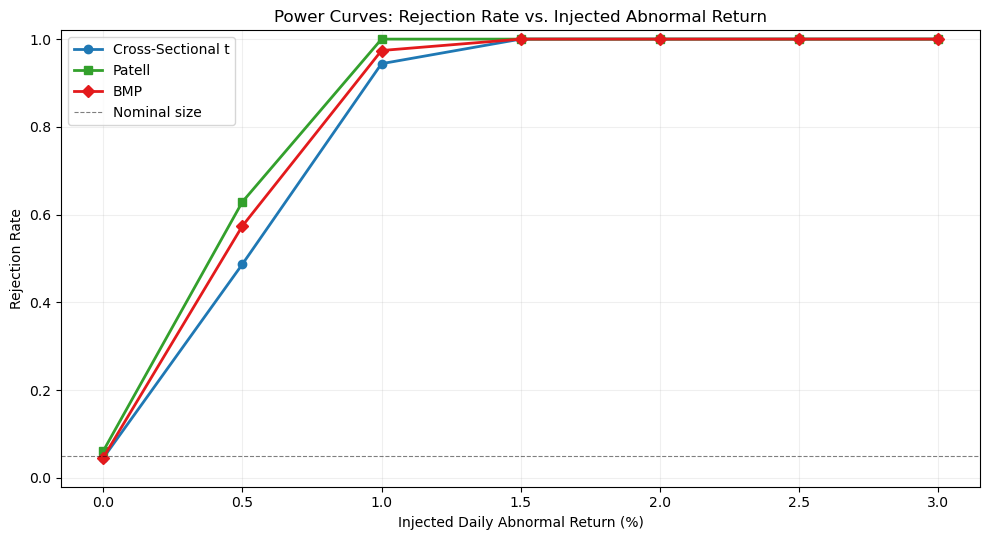

Power at selected effect sizes:
  delta = 0.0%:  CS = 0.045, Patell = 0.061, BMP = 0.046
  delta = 0.5%:  CS = 0.487, Patell = 0.629, BMP = 0.574
  delta = 1.0%:  CS = 0.944, Patell = 1.000, BMP = 0.974
  delta = 2.0%:  CS = 1.000, Patell = 1.000, BMP = 1.000
  delta = 3.0%:  CS = 1.000, Patell = 1.000, BMP = 1.000


In [37]:
# -- Power Simulation --
injected_effects = np.arange(0, 0.031, 0.005)  # 0% to 3% daily abnormal return
power_results = {test: [] for test in ['CS', 'Patell', 'BMP']}

for delta in injected_effects:
    rej = {'CS': 0, 'Patell': 0, 'BMP': 0}

    for sim in range(n_simulations):
        pseudo_ar = np.zeros((T_w, len(tickers)))
        for j, tick in enumerate(tickers):
            resid = all_residuals[tick]
            start = np.random.randint(0, len(resid) - T_w)
            pseudo_ar[:, j] = resid[start:start + T_w] + delta

        cars = pseudo_ar.sum(axis=0)
        caar = cars.mean()
        s_car = cars.std(ddof=1)
        t_cs = caar / (s_car / np.sqrt(len(tickers)))
        if abs(t_cs) > stats.t.ppf(1 - alpha_level / 2, df=len(tickers) - 1):
            rej['CS'] += 1

        sar = np.zeros((T_w, len(tickers)))
        for j, tick in enumerate(tickers):
            sar[:, j] = pseudo_ar[:, j] / model_params[tick]['sigma']
        csar = sar.sum(axis=0) / np.sqrt(T_w)
        t_patell = np.sqrt(len(tickers)) * csar.mean()
        if abs(t_patell) > stats.norm.ppf(1 - alpha_level / 2):
            rej['Patell'] += 1

        csar_mean = csar.mean()
        csar_std = csar.std(ddof=1)
        if csar_std > 0:
            t_bmp = csar_mean / (csar_std / np.sqrt(len(tickers)))
            if abs(t_bmp) > stats.t.ppf(1 - alpha_level / 2, df=len(tickers) - 1):
                rej['BMP'] += 1

    for test in rej:
        power_results[test].append(rej[test] / n_simulations)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(injected_effects * 100, power_results['CS'], 'o-', color='#1f78b4',
        linewidth=2, markersize=6, label='Cross-Sectional t')
ax.plot(injected_effects * 100, power_results['Patell'], 's-', color='#33a02c',
        linewidth=2, markersize=6, label='Patell')
ax.plot(injected_effects * 100, power_results['BMP'], 'D-', color='#e31a1c',
        linewidth=2, markersize=6, label='BMP')
ax.axhline(0.05, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Nominal size')
ax.set_xlabel('Injected Daily Abnormal Return (%)')
ax.set_ylabel('Rejection Rate')
ax.set_title('Power Curves: Rejection Rate vs. Injected Abnormal Return')
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print("Power at selected effect sizes:")
for k, delta in enumerate(injected_effects):
    if delta in [0, 0.005, 0.01, 0.02, 0.03]:
        print(f"  delta = {delta*100:.1f}%:  CS = {power_results['CS'][k]:.3f}, "
              f"Patell = {power_results['Patell'][k]:.3f}, BMP = {power_results['BMP'][k]:.3f}")

## 10. Practical Recommendations

The choice of test statistic depends on the characteristics of the sample and the research question. The following guidelines reflect the consensus in the methodological literature (Brown and Warner, 1985; Boehmer et al., 1991; Kolari and Pynnonen, 2010).

**Default choice.** The BMP test should be the primary test in most applications. It is robust to heteroskedasticity across firms and to event-induced variance, the two most common departures from the ideal assumptions. It has good power in moderate-sized samples and is straightforward to compute.

**Calendar-time clustering.** When the events cluster on a small number of calendar dates, use the Kolari-Pynnonen adjustment. In our sample, several earnings announcements coincide, so $\bar{r} > 0$ and the KP adjustment is warranted. In samples where each firm has a unique event date (e.g., randomized announcement dates, firm-specific regulatory actions), the BMP test alone is sufficient.

**Reporting convention.** It is standard practice to report at least two test statistics: typically the cross-sectional t-test and the BMP (or KP-adjusted BMP). Reporting all four, as we have done here, provides a comprehensive robustness check. If all four tests agree, the conclusion is well-supported. If the Patell test rejects but the BMP does not, event-induced variance is likely present, and the BMP conclusion should take precedence.

**Sample size.** With fewer than 20 firms, all parametric tests have limited power, and the distributional approximations (normality of the test statistic) become unreliable. In such cases, non-parametric tests (Session 5) provide a valuable complement.

**Multiple windows.** Reporting results for several event windows (as we have done) helps to characterize the timing of the price adjustment. However, testing many windows raises the multiple testing problem: with six windows at the 5% level, we expect approximately 0.3 false rejections even under the null. A Bonferroni correction (dividing the significance level by the number of windows) provides a conservative adjustment.

## 11. Summary and Preview of Session 5

This session developed the four principal parametric tests for event study inference and examined their properties through both empirical application and simulation.

The cross-sectional t-test (Brown and Warner, 1980, 1985) is the simplest and most robust to cross-sectional correlation, but sacrifices power by treating all firms equally regardless of their volatility. The Patell test (1976) standardizes abnormal returns by estimation-window volatility, improving power in heterogeneous samples, but is vulnerable to event-induced variance. The BMP test (Boehmer et al., 1991) combines Patell standardization with the cross-sectional variance estimator, achieving robustness to both heteroskedasticity and event-induced variance. The Kolari-Pynnonen (2010) adjustment deflates the BMP statistic to account for cross-sectional correlation from calendar-time clustering.

The simulation exercise showed that all three tests (CS, Patell, BMP) are approximately correctly sized when abnormal returns are cross-sectionally independent, and that the Patell test has the highest power but at the cost of robustness. The BMP test offers the best balance of size control and power for most applications.

Session 5 complements these parametric tests with non-parametric alternatives: the sign test, the rank test (Corrado, 1989), and the generalized sign test (Cowan, 1992). Non-parametric tests do not assume normally distributed abnormal returns and are particularly valuable in small samples or when the distribution of abnormal returns is skewed or heavy-tailed.

**Additional references:**

- Beaver, W.H. (1968). The Information Content of Annual Earnings Announcements. *Journal of Accounting Research*, 6, 67--92.
- Kothari, S.P. and Warner, J.B. (2007). Econometrics of Event Studies. In B.E. Eckbo (ed.), *Handbook of Empirical Corporate Finance*, Volume 1. Elsevier, Chapter 1.
- Patell, J.M. and Wolfson, M.A. (1979). Anticipated Information Releases Reflected in Call Option Prices. *Journal of Accounting and Economics*, 1(2), 117--140.
- Serra, A.P. (2002). Event Study Tests: A Brief Survey. *Working Paper*, Universidade do Porto.